# Step 4 — Combine, Compare & Include Classical ML


In [22]:
import os
while not os.path.isdir("src"):
    os.chdir("..")
print("Working directory set to repo root:", os.getcwd())

Working directory set to repo root: d:\TherapyLM-Design-Project


In [23]:
import sys
sys.path.append("src")

from multi_llm_eval import combine_saved_results, add_classical_ml_predictions, report_multi_model_metrics

In [24]:
combined = combine_saved_results()

  Loaded 500 rows for gpt-5.6-sol from results/tables/multi_llm_gpt-5_6-sol.csv
  Loaded 500 rows for gpt-5.6-terra from results/tables/multi_llm_gpt-5_6-terra.csv
  Loaded 500 rows for gemini-3.1-pro-preview from results/tables/multi_llm_gemini-3_1-pro-preview.csv
  Loaded 500 rows for gemini-3.6-flash from results/tables/multi_llm_gemini-3_6-flash.csv
  Loaded 500 rows for meta-llama-3.1-8b-instruct from results/tables/multi_llm_meta-llama-3_1-8b-instruct.csv
  Loaded 500 rows for google/gemma-4b-e4b from results/tables/multi_llm_google_gemma-4b-e4b.csv

Combined 3000 rows total -> results/tables/multi_llm_all_results.csv


In [25]:
augmented = add_classical_ml_predictions(combined)

Re-evaluating classical ML on the same 500 posts every LLM saw...
  Added SVM (LinearSVC) (500 predictions)
  Added Random Forest (500 predictions)


In [26]:
metrics = report_multi_model_metrics(augmented)

                     model            family   n  accuracy  macro_f1  weighted_f1
           SVM (LinearSVC)      Classical ML 500  0.754000  0.735134     0.750114
             Random Forest      Classical ML 500  0.718000  0.700625     0.712191
    gemini-3.1-pro-preview            Google 500  0.682000  0.604055     0.675719
          gemini-3.6-flash            Google 500  0.670000  0.595551     0.661354
               gpt-5.6-sol            OpenAI 500  0.654000  0.593785     0.644964
             gpt-5.6-terra            OpenAI 500  0.638000  0.563850     0.621626
       google/gemma-4b-e4b Local (LM Studio) 499  0.607214  0.510243     0.607412
meta-llama-3.1-8b-instruct Local (LM Studio) 500  0.550000  0.442907     0.570884

Saved results/tables/multi_llm_metrics_summary.csv and multi_llm_metrics_per_class.csv


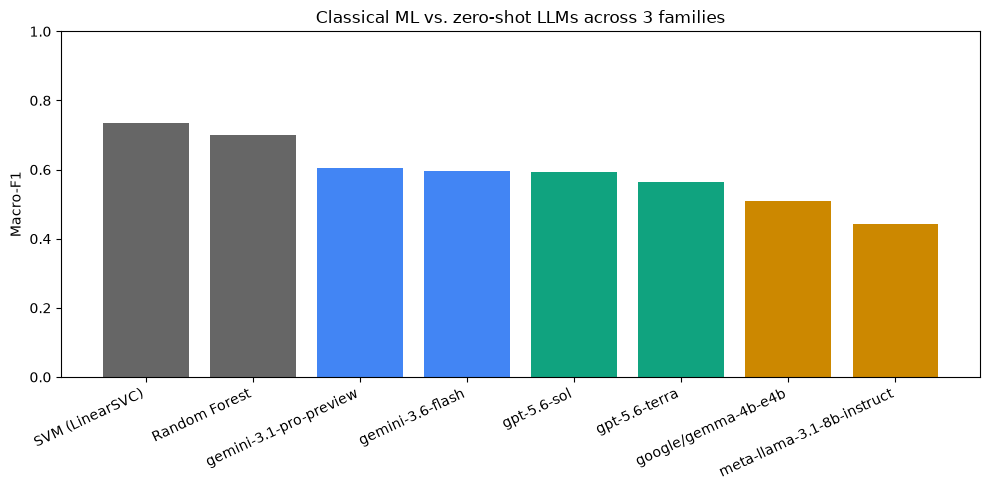

In [27]:
import matplotlib.pyplot as plt
import os
os.makedirs("results/figures", exist_ok=True)

colors = {
    "Classical ML": "#666666",
    "OpenAI": "#10a37f",
    "Google": "#4285f4",
    "Local (LM Studio)": "#cc8800",
}
bar_colors = [colors.get(f, "#333333") for f in metrics["family"]]

plt.figure(figsize=(10, 5))
plt.bar(metrics["model"], metrics["macro_f1"], color=bar_colors)
plt.ylabel("Macro-F1")
plt.title("Classical ML vs. zero-shot LLMs across 3 families")
plt.xticks(rotation=25, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig("results/figures/full_model_comparison.png", dpi=120)
plt.show()

In [28]:
llm_only = augmented[augmented["family"] != "Classical ML"]
for model, group in llm_only.groupby("model"):
    wrong = group[group["true_label"] != group["predicted_label"]]
    if len(wrong):
        top_pair = (wrong["true_label"] + " -> " + wrong["predicted_label"]).value_counts().head(1)
        print(f"{model}: top confusion = {top_pair.index[0]} ({top_pair.iloc[0]} times)")

gemini-3.1-pro-preview: top confusion = Depression -> Suicidal (37 times)
gemini-3.6-flash: top confusion = Depression -> Suicidal (41 times)
google/gemma-4b-e4b: top confusion = Depression -> Suicidal (40 times)
gpt-5.6-sol: top confusion = Depression -> Suicidal (57 times)
gpt-5.6-terra: top confusion = Depression -> Suicidal (59 times)
meta-llama-3.1-8b-instruct: top confusion = Depression -> Anxiety (40 times)
